In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
excel_file = 'cleaned_dataset_ MohammadRezaei5.xlsx'
df = pd.read_excel(excel_file)

df_sorted = df.sort_values(by='total_spending', ascending=False).reset_index(drop=True)

total_revenue = df_sorted['total_spending'].sum()
total_customers = len(df_sorted)

df_sorted['cum_customers_pct'] = (df_sorted.index + 1) / total_customers * 100
df_sorted['cum_revenue'] = df_sorted['total_spending'].cumsum()
df_sorted['cum_revenue_pct'] = df_sorted['cum_revenue'] / total_revenue * 100

top_20_count = int(np.round(total_customers * 0.20)) # 20% of 60 is 12 customers
top_20_revenue = df_sorted.iloc[:top_20_count]['total_spending'].sum()
top_20_revenue_pct = (top_20_revenue / total_revenue) * 100

print(f"Total Customers: {total_customers}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Top 20% Customers Count: {top_20_count}")
print(f"Top 20% Revenue Share: {top_20_revenue_pct:.2f}%")

top_10_count = int(np.round(total_customers * 0.10))
top_10_revenue_pct = (df_sorted.iloc[:top_10_count]['total_spending'].sum() / total_revenue) * 100

print(f"Top 10% Revenue Share: {top_10_revenue_pct:.2f}%")

print("\nFirst 15 customers cumulative stats:")
print(df_sorted[['customer_id', 'first_name', 'total_spending', 'cum_customers_pct', 'cum_revenue_pct']].head(15))

Total Customers: 60
Total Revenue: 201,985.73
Top 20% Customers Count: 12
Top 20% Revenue Share: 51.00%
Top 10% Revenue Share: 33.36%

First 15 customers cumulative stats:
    customer_id first_name  total_spending  cum_customers_pct  cum_revenue_pct
0          1044       Mina        14354.34           1.666667         7.106611
1          1057     Maryam        13532.74           3.333333        13.806460
2          1012      Arash        11731.50           5.000000        19.614544
3          1009      Kimia        11615.42           6.666667        25.365158
4          1059        Ali         8898.55           8.333333        29.770692
5          1010      Arash         7241.47          10.000000        33.355832
6          1050       Reza         6198.00          11.666667        36.424365
7          1004       Sina         6121.45          13.333333        39.455000
8          1055       Mina         6068.22          15.000000        42.459282
9          1035      Arash         591

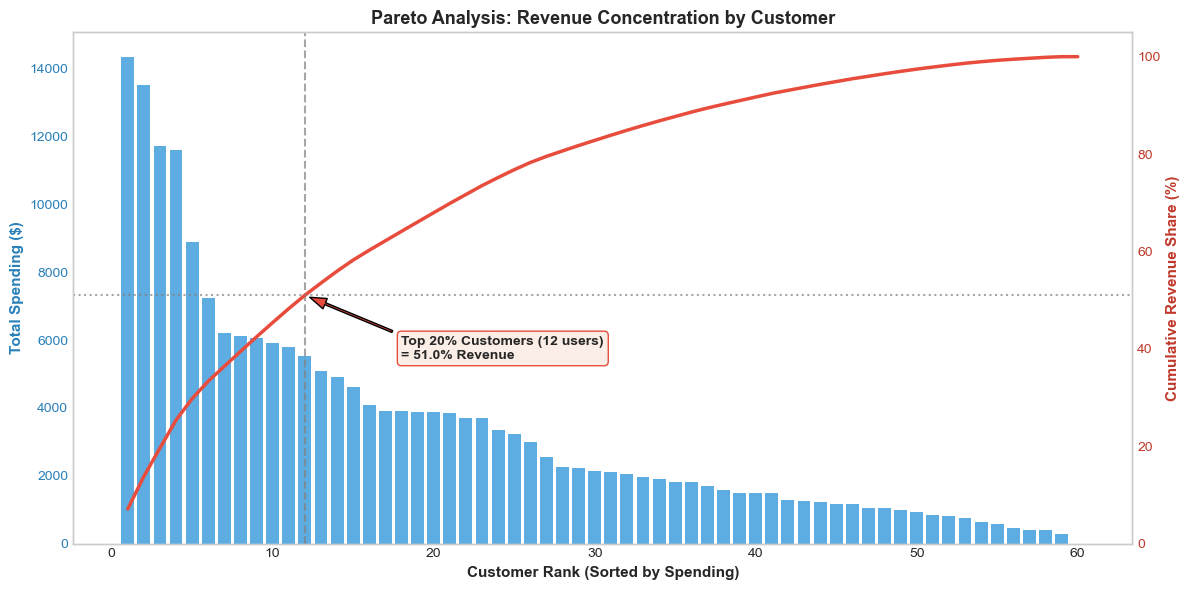

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(range(1, total_customers + 1), df_sorted['total_spending'], color='#3498db', alpha=0.8, label='Individual Spending ($)')
ax1.set_xlabel('Customer Rank (Sorted by Spending)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Spending ($)', fontsize=11, fontweight='bold', color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')

ax2 = ax1.twinx()
line = ax2.plot(range(1, total_customers + 1), df_sorted['cum_revenue_pct'], color='#e74c3c', linewidth=2.5, label='Cumulative Revenue (%)')
ax2.set_ylabel('Cumulative Revenue Share (%)', fontsize=11, fontweight='bold', color='#c0392b')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.set_ylim(0, 105)

# حذف گریدلاین‌های اضافی
ax1.grid(False)
ax2.grid(False)

ax1.axvline(12, color='gray', linestyle='--', alpha=0.7)
ax2.axhline(51.0, color='gray', linestyle=':', alpha=0.7)

ax2.annotate('Top 20% Customers (12 users)\n= 51.0% Revenue', xy=(12, 51.0), xytext=(18, 38),
             arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=1.5, headwidth=8),
             fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#fbeee6", ec="#e74c3c", lw=1))

plt.title('Pareto Analysis: Revenue Concentration by Customer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()